## ------------------------------------------------------------------------------------------------------------
## AI in Healthcare Capstone Project
### Organization: Digital Health African
### The objective is to develop a climate-aware and spatially informed Machine Learning system for predicting malaria incidence across African countries using demographic, healthcare, environmental, and temporal indicators.
### Presenter: Dr. Samuel Israel, M.Sc
### Date: 20th May, 2025
## --------------------------------------------------------------------------------------------------------------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('DatasetAfricaMalaria.csv')
df.head(3)

,Country Name,Year,Country Code,"Incidence of malaria (per 1,000 population at risk)",Malaria cases reported,Use of insecticide-treated bed nets (% of under-5 population),Children with fever receiving antimalarial drugs (% of children under age 5 with fever),Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),People using safely managed drinking water services (% of population),"People using safely managed drinking water services, rural (% of rural population)",...,Urban population growth (annual %),People using at least basic drinking water services (% of population),"People using at least basic drinking water services, rural (% of rural population)","People using at least basic drinking water services, urban (% of urban population)",People using at least basic sanitation services (% of population),"People using at least basic sanitation services, rural (% of rural population)","People using at least basic sanitation services, urban (% of urban population)",latitude,longitude,geometry
0,Algeria,2007,DZA,0.01,26.0,NaN,NaN,NaN,NaN,NaN,...,2.71,91.68,85.83,94.78,85.85,76.94,90.57,28.033886,1.659626,POINT (28.033886 1.659626)
1,Angola,2007,AGO,286.72,1533485.0,18.0,29.8,1.5,NaN,NaN,...,5.01,47.96,23.77,65.83,37.26,14.00,54.44,-11.202692,17.873887,POINT (-11.202692 17.873887)
2,Benin,2007,BEN,480.24,0.0,NaN,NaN,NaN,NaN,NaN,...,4.09,63.78,54.92,76.24,11.80,4.29,22.36,9.307690,2.315834,POINT (9.307689999999999 2.315834)


In [3]:
df.shape

(594, 27)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 27 columns):
 #   Column                                                                                   Non-Null Count  Dtype  
---  ------                                                                                   --------------  -----  
 0   Country Name                                                                             594 non-null    object 
 1   Year                                                                                     594 non-null    int64  
 2   Country Code                                                                             594 non-null    object 
 3   Incidence of malaria (per 1,000 population at risk)                                      550 non-null    float64
 4   Malaria cases reported                                                                   550 non-null    float64
 5   Use of insecticide-treated bed nets (% of under-5 population)   

In [5]:
### ---------------------------------------
#### Standardize Column Names
### --------------------------------------

In [6]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace("%", "percent", regex=False)
    .str.replace("/", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

In [7]:
df.columns

Index(['country_name', 'year', 'country_code',
       'incidence_of_malaria_per_1000_population_at_risk',
       'malaria_cases_reported',
       'use_of_insecticide_treated_bed_nets_percent_of_under_5_population',
       'children_with_fever_receiving_antimalarial_drugs_percent_of_children_under_age_5_with_fever',
       'intermittent_preventive_treatment_ipt_of_malaria_in_pregnancy_percent_of_pregnant_women',
       'people_using_safely_managed_drinking_water_services_percent_of_population',
       'people_using_safely_managed_drinking_water_services_rural_percent_of_rural_population',
       'people_using_safely_managed_drinking_water_services_urban_percent_of_urban_population',
       'people_using_safely_managed_sanitation_services_percent_of_population',
       'people_using_safely_managed_sanitation_services_rural_percent_of_rural_population',
       'people_using_safely_managed_sanitation_services_urban__percent_of_urban_population',
       'rural_population_percent_of_total_po

In [8]:
df.head(3)

,country_name,year,country_code,incidence_of_malaria_per_1000_population_at_risk,malaria_cases_reported,use_of_insecticide_treated_bed_nets_percent_of_under_5_population,children_with_fever_receiving_antimalarial_drugs_percent_of_children_under_age_5_with_fever,intermittent_preventive_treatment_ipt_of_malaria_in_pregnancy_percent_of_pregnant_women,people_using_safely_managed_drinking_water_services_percent_of_population,people_using_safely_managed_drinking_water_services_rural_percent_of_rural_population,...,urban_population_growth_annual_percent,people_using_at_least_basic_drinking_water_services_percent_of_population,people_using_at_least_basic_drinking_water_services_rural_percent_of_rural_population,people_using_at_least_basic_drinking_water_services_urban_percent_of_urban_population,people_using_at_least_basic_sanitation_services_percent_of_population,people_using_at_least_basic_sanitation_services_rural_percent_of_rural_population,people_using_at_least_basic_sanitation_services_urban__percent_of_urban_population,latitude,longitude,geometry
0,Algeria,2007,DZA,0.01,26.0,NaN,NaN,NaN,NaN,NaN,...,2.71,91.68,85.83,94.78,85.85,76.94,90.57,28.033886,1.659626,POINT (28.033886 1.659626)
1,Angola,2007,AGO,286.72,1533485.0,18.0,29.8,1.5,NaN,NaN,...,5.01,47.96,23.77,65.83,37.26,14.00,54.44,-11.202692,17.873887,POINT (-11.202692 17.873887)
2,Benin,2007,BEN,480.24,0.0,NaN,NaN,NaN,NaN,NaN,...,4.09,63.78,54.92,76.24,11.80,4.29,22.36,9.307690,2.315834,POINT (9.307689999999999 2.315834)


In [9]:
### ---------------------------------------
#### Check Missing Values
### --------------------------------------

In [10]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

people_using_safely_managed_drinking_water_services_rural_percent_of_rural_population          506
people_using_safely_managed_drinking_water_services_percent_of_population                      495
intermittent_preventive_treatment_ipt_of_malaria_in_pregnancy_percent_of_pregnant_women        488
people_using_safely_managed_sanitation_services_rural_percent_of_rural_population              484
children_with_fever_receiving_antimalarial_drugs_percent_of_children_under_age_5_with_fever    472
people_using_safely_managed_sanitation_services_urban__percent_of_urban_population             462
people_using_safely_managed_sanitation_services_percent_of_population                          462
use_of_insecticide_treated_bed_nets_percent_of_under_5_population                              462
people_using_safely_managed_drinking_water_services_urban_percent_of_urban_population          418
malaria_cases_reported                                                                          44
incidence_

In [11]:
### ---------------------------------------
#### Check Missing Percentage
### --------------------------------------

In [12]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percent
}).sort_values(by="Missing Percentage", ascending=False)

missing_table

,Missing Values,Missing Percentage
people_using_safely_managed_drinking_water_services_rural_percent_of_rural_population,506,85.185185
people_using_safely_managed_drinking_water_services_percent_of_population,495,83.333333
intermittent_preventive_treatment_ipt_of_malaria_in_pregnancy_percent_of_pregnant_women,488,82.154882
people_using_safely_managed_sanitation_services_rural_percent_of_rural_population,484,81.481481
children_with_fever_receiving_antimalarial_drugs_percent_of_children_under_age_5_with_fever,472,79.461279
people_using_safely_managed_sanitation_services_urban__percent_of_urban_population,462,77.777778
people_using_safely_managed_sanitation_services_percent_of_population,462,77.777778
use_of_insecticide_treated_bed_nets_percent_of_under_5_population,462,77.777778
people_using_safely_managed_drinking_water_services_urban_percent_of_urban_population,418,70.370370
malaria_cases_reported,44,7.407407


In [13]:
### ---------------------------------------
#### Drop columns with more than 40% missing values
### --------------------------------------

In [14]:
threshold = 40

cols_to_drop = missing_table[
    missing_table["Missing Percentage"] > threshold
].index

cols_to_drop

Index(['people_using_safely_managed_drinking_water_services_rural_percent_of_rural_population',
       'people_using_safely_managed_drinking_water_services_percent_of_population',
       'intermittent_preventive_treatment_ipt_of_malaria_in_pregnancy_percent_of_pregnant_women',
       'people_using_safely_managed_sanitation_services_rural_percent_of_rural_population',
       'children_with_fever_receiving_antimalarial_drugs_percent_of_children_under_age_5_with_fever',
       'people_using_safely_managed_sanitation_services_urban__percent_of_urban_population',
       'people_using_safely_managed_sanitation_services_percent_of_population',
       'use_of_insecticide_treated_bed_nets_percent_of_under_5_population',
       'people_using_safely_managed_drinking_water_services_urban_percent_of_urban_population'],
      dtype='object')

In [15]:
df = df.drop(columns=cols_to_drop)

In [16]:
#Verify
missing_table_after_drop = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
}).sort_values(by="Missing Percentage", ascending=False)

missing_table_after_drop

,Missing Values,Missing Percentage
incidence_of_malaria_per_1000_population_at_risk,44,7.407407
malaria_cases_reported,44,7.407407
people_using_at_least_basic_sanitation_services_urban__percent_of_urban_population,28,4.713805
people_using_at_least_basic_drinking_water_services_rural_percent_of_rural_population,28,4.713805
people_using_at_least_basic_drinking_water_services_urban_percent_of_urban_population,28,4.713805
people_using_at_least_basic_sanitation_services_rural_percent_of_rural_population,28,4.713805
people_using_at_least_basic_drinking_water_services_percent_of_population,6,1.010101
rural_population_percent_of_total_population,6,1.010101
rural_population_growth_annual_percent,6,1.010101
urban_population_percent_of_total_population,6,1.010101


In [17]:
### ---------------------------------------
#### fill the remaining missing values
### --------------------------------------

In [18]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [19]:
#Verify
df.isnull().sum().sum()

np.int64(0)

In [20]:
df.head(3)

,country_name,year,country_code,incidence_of_malaria_per_1000_population_at_risk,malaria_cases_reported,rural_population_percent_of_total_population,rural_population_growth_annual_percent,urban_population_percent_of_total_population,urban_population_growth_annual_percent,people_using_at_least_basic_drinking_water_services_percent_of_population,people_using_at_least_basic_drinking_water_services_rural_percent_of_rural_population,people_using_at_least_basic_drinking_water_services_urban_percent_of_urban_population,people_using_at_least_basic_sanitation_services_percent_of_population,people_using_at_least_basic_sanitation_services_rural_percent_of_rural_population,people_using_at_least_basic_sanitation_services_urban__percent_of_urban_population,latitude,longitude,geometry
0,Algeria,2007,DZA,0.01,26.0,34.65,-0.60,65.35,2.71,91.68,85.83,94.78,85.85,76.94,90.57,28.033886,1.659626,POINT (28.033886 1.659626)
1,Angola,2007,AGO,286.72,1533485.0,42.48,1.91,57.52,5.01,47.96,23.77,65.83,37.26,14.00,54.44,-11.202692,17.873887,POINT (-11.202692 17.873887)
2,Benin,2007,BEN,480.24,0.0,58.44,1.99,41.56,4.09,63.78,54.92,76.24,11.80,4.29,22.36,9.307690,2.315834,POINT (9.307689999999999 2.315834)


In [21]:
#Drop country_code & geometry

df = df.drop(columns=['country_code','geometry'], errors='ignore')

In [22]:
#Rename countryname to country

df = df.rename(columns={
    'country_name': 'country'
})

In [23]:
df.head(3)

,country,year,incidence_of_malaria_per_1000_population_at_risk,malaria_cases_reported,rural_population_percent_of_total_population,rural_population_growth_annual_percent,urban_population_percent_of_total_population,urban_population_growth_annual_percent,people_using_at_least_basic_drinking_water_services_percent_of_population,people_using_at_least_basic_drinking_water_services_rural_percent_of_rural_population,people_using_at_least_basic_drinking_water_services_urban_percent_of_urban_population,people_using_at_least_basic_sanitation_services_percent_of_population,people_using_at_least_basic_sanitation_services_rural_percent_of_rural_population,people_using_at_least_basic_sanitation_services_urban__percent_of_urban_population,latitude,longitude
0,Algeria,2007,0.01,26.0,34.65,-0.60,65.35,2.71,91.68,85.83,94.78,85.85,76.94,90.57,28.033886,1.659626
1,Angola,2007,286.72,1533485.0,42.48,1.91,57.52,5.01,47.96,23.77,65.83,37.26,14.00,54.44,-11.202692,17.873887
2,Benin,2007,480.24,0.0,58.44,1.99,41.56,4.09,63.78,54.92,76.24,11.80,4.29,22.36,9.307690,2.315834


In [24]:
### ---------------------------------------
#### Save Clean Dataset
### --------------------------------------

In [25]:
df.to_csv(
    "cleaned_malaria_dataset.csv",
    index=False
)

In [26]:
### ---------------------------------------
#### Import Rainfall Dataset
### --------------------------------------

In [27]:
rainfall = pd.read_csv('rainfall dataset.csv',skiprows=4)
rainfall.head(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Aruba,ABW,Average precipitation in depth (mm per year),AG.LND.PRCP.MM,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Average precipitation in depth (mm per year),AG.LND.PRCP.MM,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Average precipitation in depth (mm per year),AG.LND.PRCP.MM,NaN,327.0,327.0,327.0,327.0,327.0,...,327.0,327.0,327.0,327.0,327.0,327.0,327.0,NaN,NaN,NaN


In [28]:
### ---------------------------------------
#### Drop Redundant Columns
### --------------------------------------

In [29]:
rainfall = rainfall.drop(
    columns=[
        "Country Code",
        "Indicator Name",
        "Indicator Code"
    ]
)

rainfall = rainfall.melt(
    id_vars=["Country Name"],
    var_name="year",
    value_name="rainfall"
)

rainfall = rainfall.rename(columns={
    "Country Name": "country"
})

rainfall = rainfall[
    rainfall["year"].str.isnumeric()
]

rainfall["year"] = rainfall["year"].astype(int)

rainfall.head()

,country,year,rainfall
0,Aruba,1960,NaN
1,Africa Eastern and Southern,1960,NaN
2,Afghanistan,1960,NaN
3,Africa Western and Central,1960,NaN
4,Angola,1960,NaN


In [30]:
### ---------------------------------------
#### Check for Missing Values
### --------------------------------------

In [31]:
rainfall['rainfall'].isnull().sum()

np.int64(7108)

In [32]:
### ---------------------------------------
#### Get African Countries From Your Malaria Dataset
### --------------------------------------

In [33]:
african_countries = df['country'].unique()

In [34]:
#Filter Rainfall Dataset
rainfall = rainfall[
    rainfall['country'].isin(african_countries)
]

In [35]:
#Check Missing Values Again
rainfall['rainfall'].isnull().sum()

np.int64(378)

In [36]:
#Fill Missing Values Country-wise
rainfall['rainfall'] = rainfall.groupby('country')['rainfall'].transform(
    lambda x: x.fillna(x.median())
)

In [37]:
#Final Check
rainfall['rainfall'].isnull().sum()

np.int64(0)

In [38]:
### ---------------------------------------
#### Save Clean Rainfall Dataset
### --------------------------------------

In [39]:
df.to_csv(
    "cleaned_rainfall_dataset.csv",
    index=False
)

In [40]:
### ---------------------------------------
#### Import Temperature Dataset
### --------------------------------------

In [41]:
temperature = pd.read_csv('combined_temperature.csv')
temperature.head(3)

,Country,Year,Annual Mean,5-yr smooth,Code
0,Dominican Republic,1901,23.71,23.65,DOM
1,Dominican Republic,1902,23.40,23.52,DOM
2,Dominican Republic,1903,23.45,23.38,DOM


In [42]:
temperature.columns

Index(['Country', 'Year', 'Annual Mean', '5-yr smooth', 'Code'], dtype='object')

In [43]:
### ---------------------------------------
#### Rename Columns
### --------------------------------------

In [44]:
temperature = temperature.rename(columns={
    'Country': 'country',
    'Year': 'year',
    'Annual Mean': 'temperature'
})

In [45]:
#Keep needed columns
temperature = temperature[
    ['country', 'year', 'temperature']
]

In [46]:
### ---------------------------------------
#### Filter Only African Countries
### --------------------------------------

In [47]:
african_countries = df['country'].unique()

temperature = temperature[
    temperature['country'].isin(african_countries)
]

In [48]:
### ---------------------------------------
#### Check Missing Values
### --------------------------------------

In [49]:
temperature.isnull().sum()

country        0
year           0
temperature    0
dtype: int64

In [50]:
### ---------------------------------------
#### Merge Rainfall & Temperature Datasets
### --------------------------------------

In [51]:
climate_df = pd.merge(
    rainfall,
    temperature,
    on=['country', 'year'],
    how='inner'
)

In [52]:
#Verify
climate_df.head()

,country,year,rainfall,temperature
0,Angola,1960,1010.0,21.45
1,Burundi,1960,1274.0,19.85
2,Benin,1960,1039.0,27.43
3,Botswana,1960,416.0,21.35
4,Central African Republic,1960,1343.0,25.34


In [53]:

climate_df.shape

(2709, 4)

In [54]:
### ---------------------------------------
#### Merge the final Datasets
### --------------------------------------

In [55]:
final_df = pd.merge(
    df,
    climate_df,
    on=['country', 'year'],
    how='left'
)

In [56]:
final_df.isnull().sum()

country                                                                                    0
year                                                                                       0
incidence_of_malaria_per_1000_population_at_risk                                           0
malaria_cases_reported                                                                     0
rural_population_percent_of_total_population                                               0
rural_population_growth_annual_percent                                                     0
urban_population_percent_of_total_population                                               0
urban_population_growth_annual_percent                                                     0
people_using_at_least_basic_drinking_water_services_percent_of_population                  0
people_using_at_least_basic_drinking_water_services_rural_percent_of_rural_population      0
people_using_at_least_basic_drinking_water_services_urban_percent_of_u

In [57]:
### ---------------------------------------
#### SAVE THIS MERGED CLEAN DATASET
### --------------------------------------

In [58]:
final_df.to_csv(
    "final_merged_malaria_climate_dataset.csv",
    index=False
)

In [59]:
### ---------------------------------------
#### Feature Engineering
### --------------------------------------

In [60]:
#Create Copy of Final Dataset
advanced_df = final_df.copy()

In [61]:
#Sort Dataset
advanced_df = advanced_df.sort_values(
    ['country', 'year']
)

In [62]:
### Rainfall Lag Features

In [63]:
#Previous Year Rainfall
advanced_df['rainfall_lag_1'] = (
    advanced_df.groupby('country')['rainfall']
    .shift(1)
)

In [64]:
#2-Year Rainfall Lag
advanced_df['rainfall_lag_2'] = (
    advanced_df.groupby('country')['rainfall']
    .shift(2)
)

In [65]:
### ---------------------------------------
###### Temperature Lag Features
### --------------------------------------

In [66]:
#Previous Year Temperature
advanced_df['temperature_lag_1'] = (
    advanced_df.groupby('country')['temperature']
    .shift(1)
)

In [67]:
#2-Year Temperature Lag
advanced_df['temperature_lag_2'] = (
    advanced_df.groupby('country')['temperature']
    .shift(2)
)

In [68]:
### ---------------------------------------
###### Malaria Incidence Lag Features
### --------------------------------------

In [69]:
#Previous Year Incidence
advanced_df['malaria_incidence_lag_1'] = (
    advanced_df.groupby('country')
    ['incidence_of_malaria_per_1000_population_at_risk']
    .shift(1)
)

In [70]:
#2-Year Incidence Lag
advanced_df['malaria_incidence_lag_2'] = (
    advanced_df.groupby('country')
    ['incidence_of_malaria_per_1000_population_at_risk']
    .shift(2)
)

In [71]:
### ---------------------------------------
###### Fill Lag Feature Missing Values
### --------------------------------------

In [72]:
lag_columns = [
    'rainfall_lag_1',
    'rainfall_lag_2',
    'temperature_lag_1',
    'temperature_lag_2',
    'malaria_incidence_lag_1',
    'malaria_incidence_lag_2'
]

for col in lag_columns:
    advanced_df[col] = advanced_df[col].fillna(
        advanced_df[col].median()
    )

In [73]:
### ---------------------------------------
###### Rolling Climate Averages
### --------------------------------------

In [74]:
#3-Year Average Rainfall
advanced_df['rainfall_3yr_avg'] = (
    advanced_df.groupby('country')['rainfall']
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=1
        ).mean()
    )
)

In [75]:
#3-Year Average Temperature
advanced_df['temperature_3yr_avg'] = (
    advanced_df.groupby('country')['temperature']
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=1
        ).mean()
    )
)

In [76]:
### ---------------------------------------
###### Climate-Risk Interaction Features
### --------------------------------------

In [77]:
#Rainfall & Temperature
advanced_df['climate_risk_index'] = (
    advanced_df['rainfall'] *
    advanced_df['temperature']
)

In [78]:
#Rainfall & Rural Population
advanced_df['rainfall_rural_interaction'] = (
    advanced_df['rainfall'] *
    advanced_df['rural_population_percent_of_total_population']
)

In [79]:
### ---------------------------------------
###### Temporal Trend Features
### --------------------------------------

In [80]:
#Years Since Start
advanced_df['years_since_start'] = (
    advanced_df['year'] -
    advanced_df['year'].min()
)

In [81]:
#Decade Feature
advanced_df['decade'] = (
    advanced_df['year'] // 10
) * 10

In [82]:
### ---------------------------------------
###### Spatially Aware Features
### --------------------------------------

In [83]:
#Latitude & Temperature
advanced_df['latitude_temperature_interaction'] = (
    advanced_df['latitude'] *
    advanced_df['temperature']
)

In [84]:
#Longitude & Rainfall
advanced_df['longitude_rainfall_interaction'] = (
    advanced_df['longitude'] *
    advanced_df['rainfall']
)

In [85]:
### ---------------------------------------
###### Create Malaria Risk Classification
### --------------------------------------

In [86]:
median_incidence = (
    advanced_df[
        'incidence_of_malaria_per_1000_population_at_risk'
    ].median()
)

advanced_df['high_risk_region'] = np.where(
    advanced_df[
        'incidence_of_malaria_per_1000_population_at_risk'
    ] > median_incidence,
    1,
    0
)

In [87]:
### ---------------------------------------
#### Final Dataset Check
### --------------------------------------

In [88]:
advanced_df.head(3)

,country,year,incidence_of_malaria_per_1000_population_at_risk,malaria_cases_reported,rural_population_percent_of_total_population,rural_population_growth_annual_percent,urban_population_percent_of_total_population,urban_population_growth_annual_percent,people_using_at_least_basic_drinking_water_services_percent_of_population,people_using_at_least_basic_drinking_water_services_rural_percent_of_rural_population,...,malaria_incidence_lag_2,rainfall_3yr_avg,temperature_3yr_avg,climate_risk_index,rainfall_rural_interaction,years_since_start,decade,latitude_temperature_interaction,longitude_rainfall_interaction,high_risk_region
0,Algeria,2007,0.01,26.0,34.65,-0.60,65.35,2.71,91.68,85.83,...,174.775,89.0,23.580000,2098.62,3083.85,0,2000,661.039032,147.706714,0
54,Algeria,2008,0.00,3.0,33.90,-0.55,66.10,2.78,91.92,86.19,...,174.775,89.0,23.505000,2085.27,3017.10,1,2000,656.833949,147.706714,0
108,Algeria,2009,0.00,0.0,33.17,-0.45,66.83,2.82,92.16,86.54,...,0.010,89.0,23.626667,2124.43,2952.13,2,2000,669.168859,147.706714,0


In [89]:
advanced_df.shape

(594, 33)

In [90]:
advanced_df.columns

Index(['country', 'year', 'incidence_of_malaria_per_1000_population_at_risk',
       'malaria_cases_reported',
       'rural_population_percent_of_total_population',
       'rural_population_growth_annual_percent',
       'urban_population_percent_of_total_population',
       'urban_population_growth_annual_percent',
       'people_using_at_least_basic_drinking_water_services_percent_of_population',
       'people_using_at_least_basic_drinking_water_services_rural_percent_of_rural_population',
       'people_using_at_least_basic_drinking_water_services_urban_percent_of_urban_population',
       'people_using_at_least_basic_sanitation_services_percent_of_population',
       'people_using_at_least_basic_sanitation_services_rural_percent_of_rural_population',
       'people_using_at_least_basic_sanitation_services_urban__percent_of_urban_population',
       'latitude', 'longitude', 'rainfall', 'temperature', 'rainfall_lag_1',
       'rainfall_lag_2', 'temperature_lag_1', 'temperature_lag_

In [91]:
advanced_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 594 entries, 0 to 593
Data columns (total 33 columns):
 #   Column                                                                                 Non-Null Count  Dtype  
---  ------                                                                                 --------------  -----  
 0   country                                                                                594 non-null    object 
 1   year                                                                                   594 non-null    int64  
 2   incidence_of_malaria_per_1000_population_at_risk                                       594 non-null    float64
 3   malaria_cases_reported                                                                 594 non-null    float64
 4   rural_population_percent_of_total_population                                           594 non-null    float64
 5   rural_population_growth_annual_percent                                             

In [92]:
advanced_df.isnull().sum()

country                                                                                    0
year                                                                                       0
incidence_of_malaria_per_1000_population_at_risk                                           0
malaria_cases_reported                                                                     0
rural_population_percent_of_total_population                                               0
rural_population_growth_annual_percent                                                     0
urban_population_percent_of_total_population                                               0
urban_population_growth_annual_percent                                                     0
people_using_at_least_basic_drinking_water_services_percent_of_population                  0
people_using_at_least_basic_drinking_water_services_rural_percent_of_rural_population      0
people_using_at_least_basic_drinking_water_services_urban_percent_of_u

In [93]:
# Check total duplicate rows
advanced_df.duplicated().sum()

np.int64(0)

In [94]:
### ---------------------------------------
#### Save Feature Engineered Dataset
### --------------------------------------

In [95]:
advanced_df.to_csv(
    "advanced_feature_engineered_malaria_dataset.csv",
    index=False
)

In [96]:
### ---------------------------------------
#### . Statistical Summary
### --------------------------------------

In [97]:
#Select Numerical Features
numeric_df = advanced_df.select_dtypes(
    include=['int64', 'float64']
)

In [98]:
#Statistical Summary
numeric_df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,594.0,2012.000000,3.164943e+00,2007.000000,2009.000000,2012.000000,2.015000e+03,2.017000e+03
incidence_of_malaria_per_1000_population_at_risk,594.0,188.953232,1.569400e+02,0.000000,35.355000,174.775000,3.373675e+02,5.855400e+02
malaria_cases_reported,594.0,997566.823232,2.124689e+06,0.000000,3705.750000,113026.000000,1.041084e+06,1.682113e+07
rural_population_percent_of_total_population,594.0,56.852896,1.799532e+01,11.020000,43.635000,58.445000,7.037250e+01,9.014000e+01
rural_population_growth_annual_percent,594.0,1.392256,1.193951e+00,-3.450000,0.412500,1.675000,2.127500e+00,7.090000e+00
urban_population_percent_of_total_population,594.0,43.147912,1.799510e+01,9.860000,29.627500,41.560000,5.636500e+01,8.898000e+01
urban_population_growth_annual_percent,594.0,3.525152,1.449006e+00,-4.650000,2.522500,3.730000,4.435000e+00,7.400000e+00
people_using_at_least_basic_drinking_water_services_percent_of_population,594.0,65.979512,1.719638e+01,28.960000,52.517500,64.470000,7.894250e+01,9.987000e+01
people_using_at_least_basic_drinking_water_services_rural_percent_of_rural_population,594.0,51.401751,1.847685e+01,17.050000,37.465000,50.435000,6.140500e+01,9.983000e+01
people_using_at_least_basic_drinking_water_services_urban_percent_of_urban_population,594.0,84.322778,9.088177e+00,52.010000,78.387500,85.420000,8.986500e+01,9.992000e+01


In [99]:
### ---------------------------------------
#### Outlier Detection
### --------------------------------------

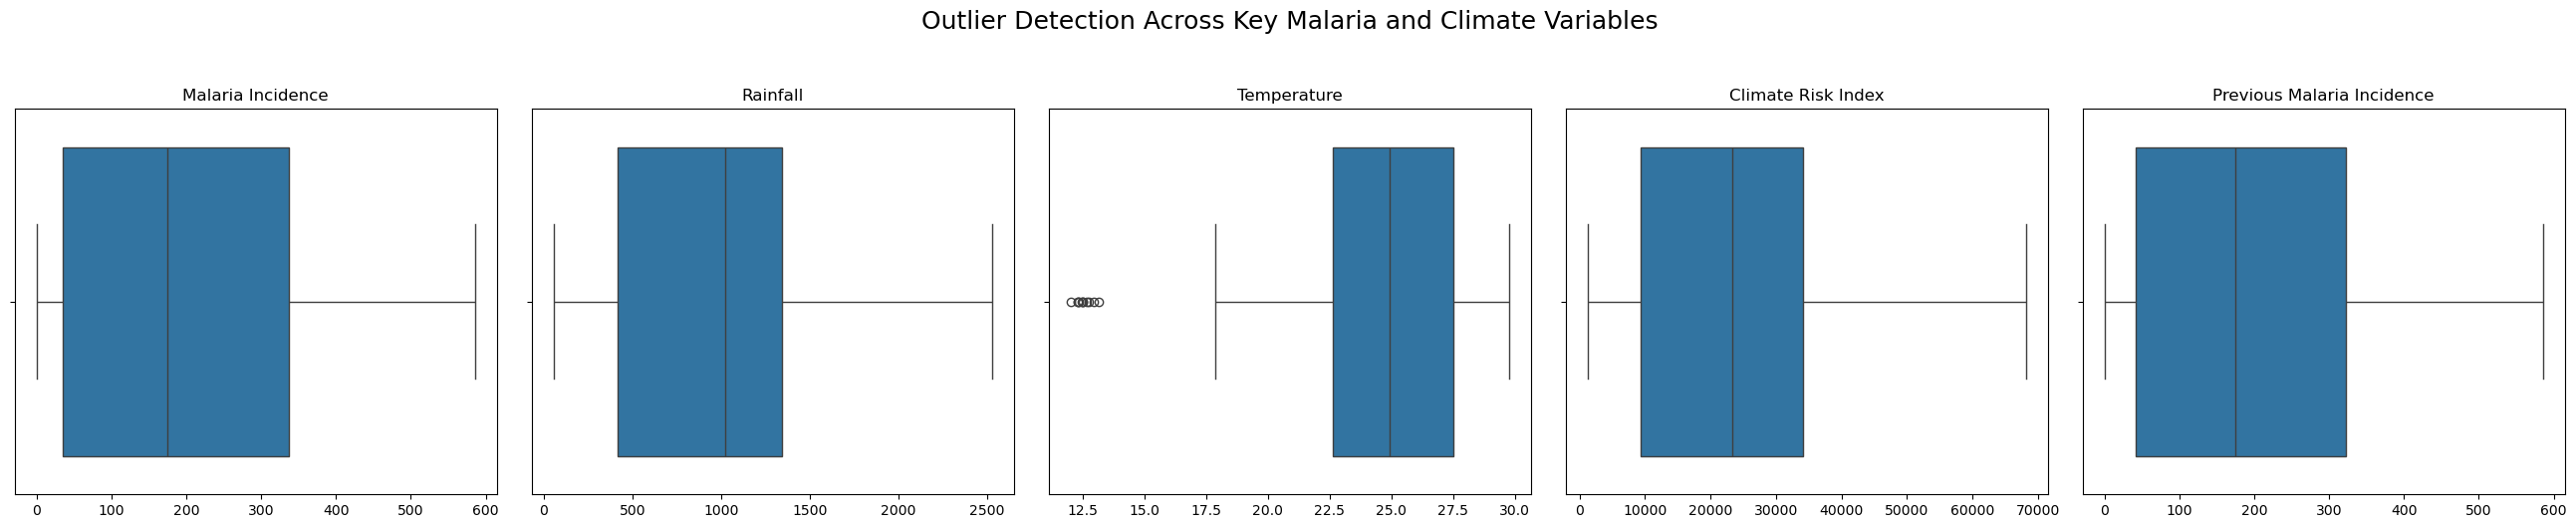

In [100]:
#Boxplots for Key Variables
import matplotlib.pyplot as plt
import seaborn as sns

plt.close("all")

features = [
    "incidence_of_malaria_per_1000_population_at_risk",
    "rainfall",
    "temperature",
    "climate_risk_index",
    "malaria_incidence_lag_1"
]

titles = [
    "Malaria Incidence",
    "Rainfall",
    "Temperature",
    "Climate Risk Index",
    "Previous Malaria Incidence"
]

fig, axes = plt.subplots(1, 5, figsize=(26, 5))

for ax, feature, title in zip(axes, features, titles):
    sns.boxplot(
        x=advanced_df[feature],
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("")

fig.suptitle(
    "Outlier Detection Across Key Malaria and Climate Variables",
    fontsize=18,
    y=1.05
)

plt.tight_layout()
plt.show()

In [101]:
#IQR-Based Outlier Detection
def detect_outliers_iqr(data, column):
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]
    
    return outliers

In [102]:
#Detect Outliers for Malaria Incidence
malaria_outliers = detect_outliers_iqr(
    advanced_df,
    'incidence_of_malaria_per_1000_population_at_risk'
)

malaria_outliers.shape

(0, 33)

In [103]:
#Detect Outliers for Climate Variables
#Rainfall
rainfall_outliers = detect_outliers_iqr(
    advanced_df,
    'rainfall'
)

rainfall_outliers.shape

(0, 33)

In [104]:
#Temperature
temperature_outliers = detect_outliers_iqr(
    advanced_df,
    'temperature'
)

temperature_outliers.shape

(11, 33)

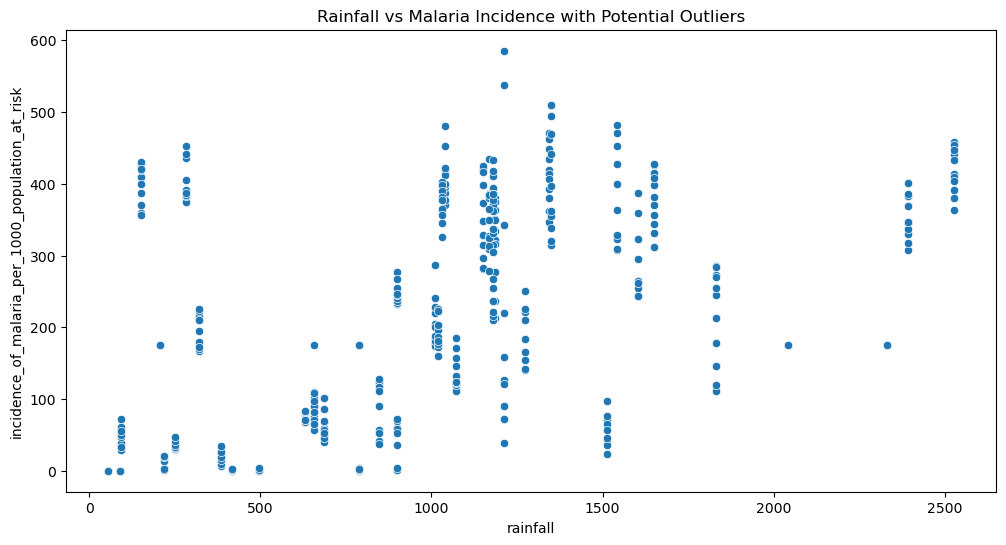

In [105]:
#Visualize Outliers: Rainfall vs Malaria
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=advanced_df,
    x='rainfall',
    y='incidence_of_malaria_per_1000_population_at_risk'
)

plt.title("Rainfall vs Malaria Incidence with Potential Outliers")

plt.show()

In [106]:
### ---------------------------------------
#### Exploratory Data Analysis (EDA)
### --------------------------------------

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("default")

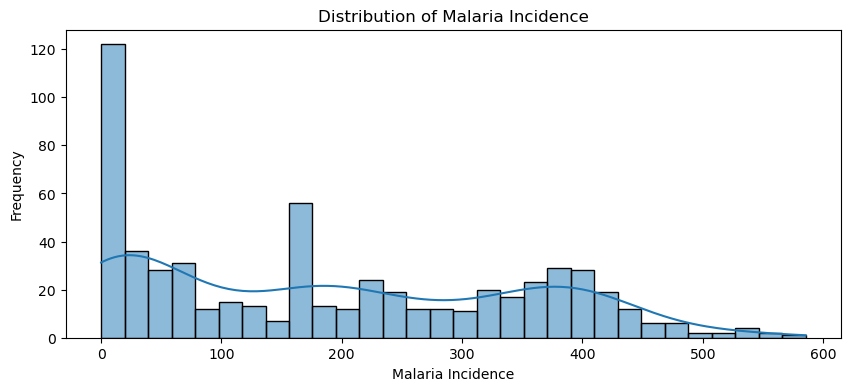

In [109]:
#Distribution of Malaria Incidence
plt.figure(figsize=(10,4))

sns.histplot(
    advanced_df[
        'incidence_of_malaria_per_1000_population_at_risk'
    ],
    bins=30,
    kde=True
)

plt.title("Distribution of Malaria Incidence")
plt.xlabel("Malaria Incidence")
plt.ylabel("Frequency")

plt.show()

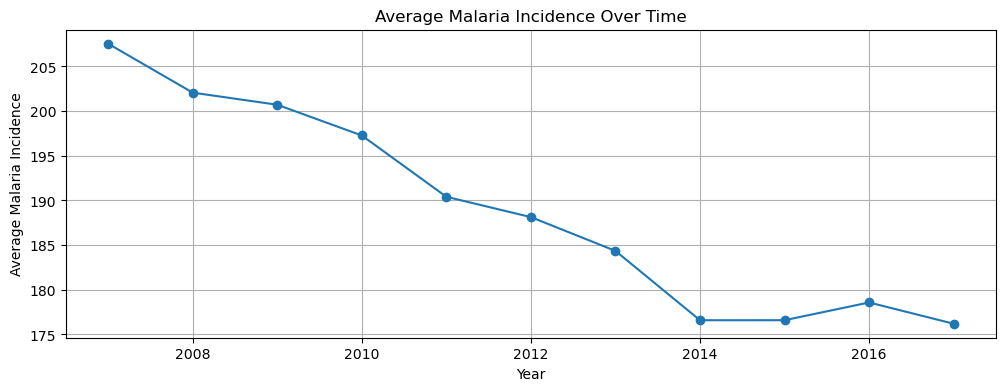

In [110]:
#Malaria Trend Over Time
yearly_trend = (
    advanced_df.groupby('year')
    ['incidence_of_malaria_per_1000_population_at_risk']
    .mean()
)

plt.figure(figsize=(12,4))

plt.plot(
    yearly_trend.index,
    yearly_trend.values,
    marker='o'
)

plt.title("Average Malaria Incidence Over Time")
plt.xlabel("Year")
plt.ylabel("Average Malaria Incidence")

plt.grid(True)

plt.show()

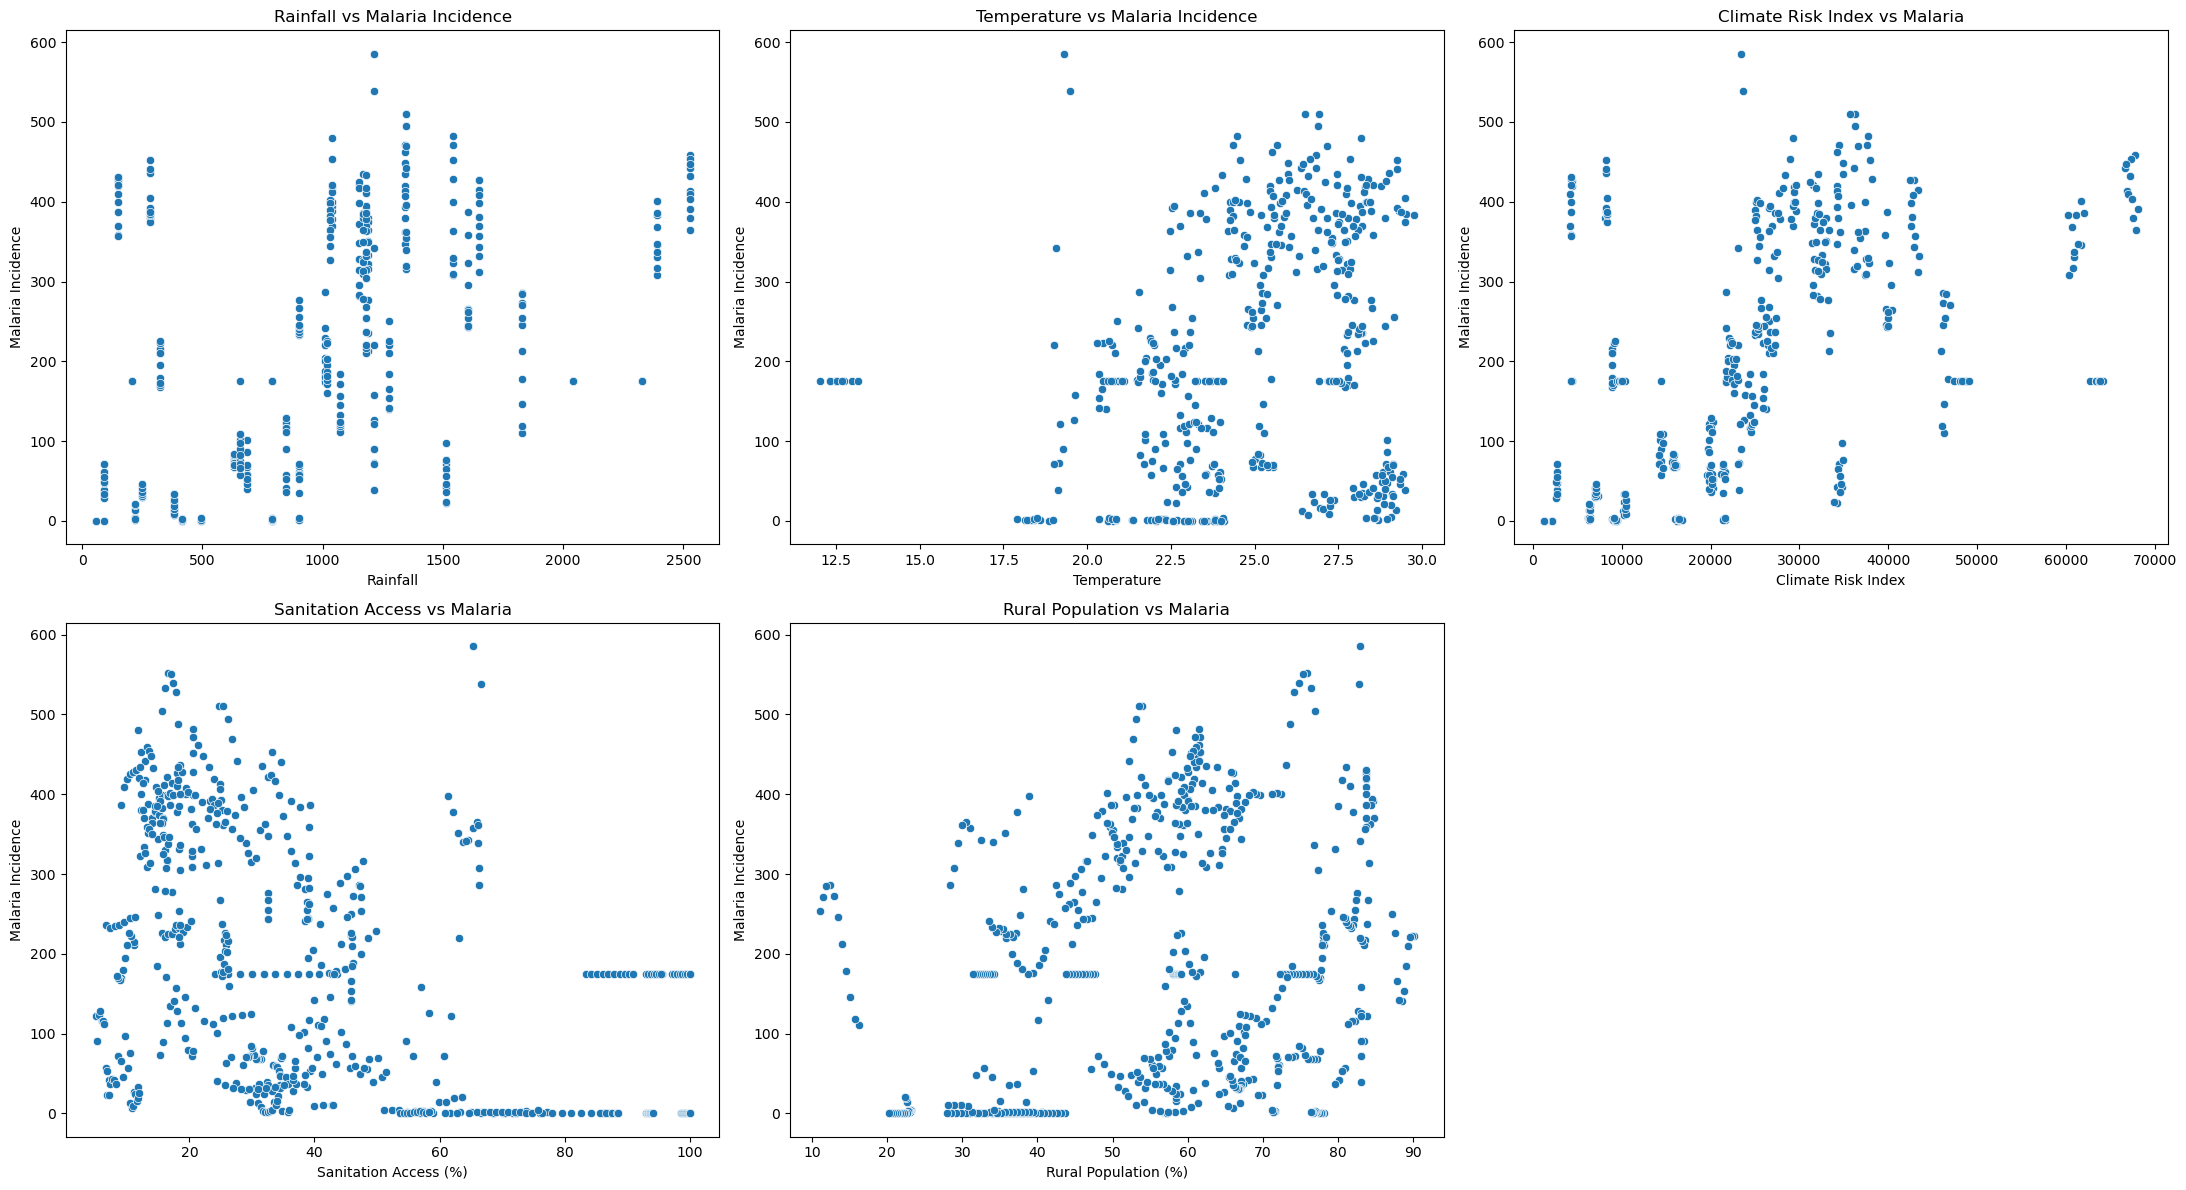

In [110]:
#Climate, Environmental, and Socio-Demographic Factors Associated with Malaria Incidence Across African Countries
import matplotlib.pyplot as plt
import seaborn as sns

target = "incidence_of_malaria_per_1000_population_at_risk"

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

plots = [
    ("rainfall", "Rainfall vs Malaria Incidence", "Rainfall"),
    ("temperature", "Temperature vs Malaria Incidence", "Temperature"),
    ("climate_risk_index", "Climate Risk Index vs Malaria", "Climate Risk Index"),
    ("people_using_at_least_basic_sanitation_services_percent_of_population", 
     "Sanitation Access vs Malaria", "Sanitation Access (%)"),
    ("rural_population_percent_of_total_population", 
     "Rural Population vs Malaria", "Rural Population (%)")
]

for i, (x_col, title, xlabel) in enumerate(plots):
    sns.scatterplot(
        data=advanced_df,
        x=x_col,
        y=target,
        ax=axes[i]
    )
    axes[i].set_title(title)
    axes[i].set_xlabel(xlabel)
    axes[i].set_ylabel("Malaria Incidence")

# Remove empty 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

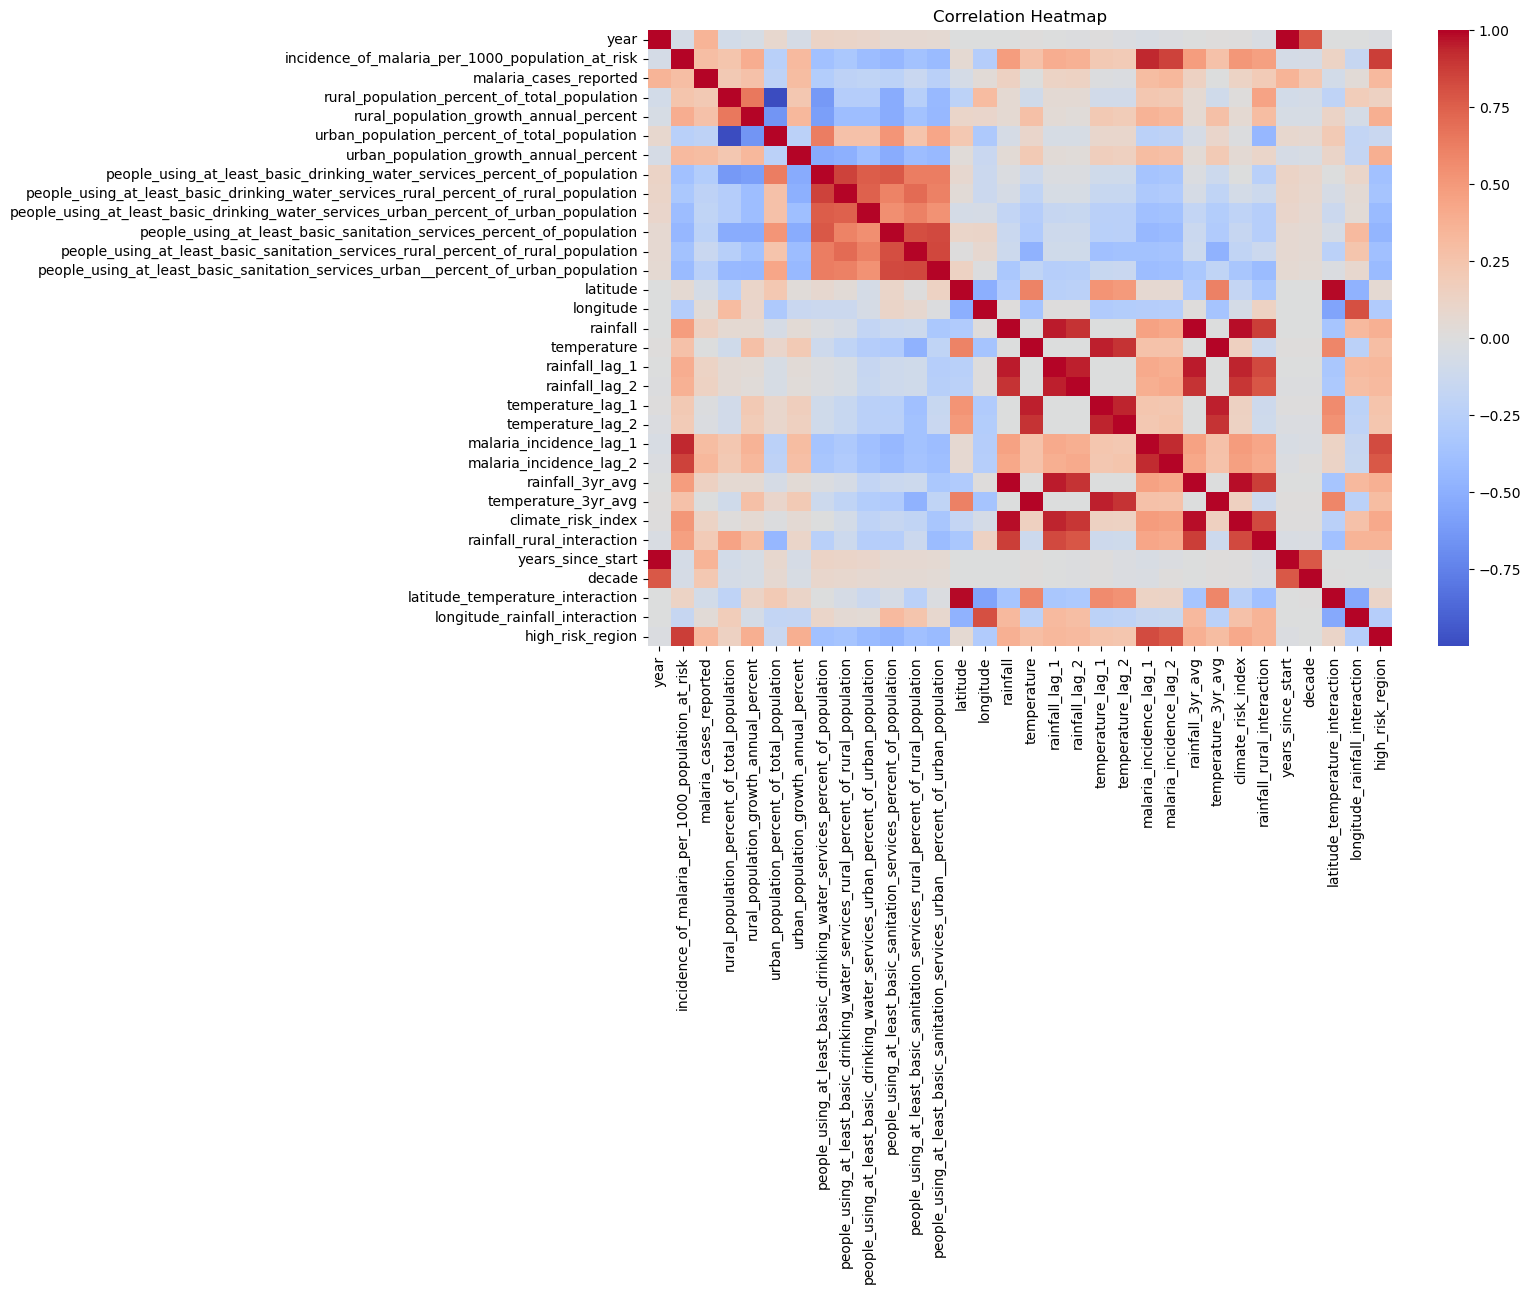

In [111]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

numeric_df = advanced_df.select_dtypes(
    include=['int64', 'float64']
)

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

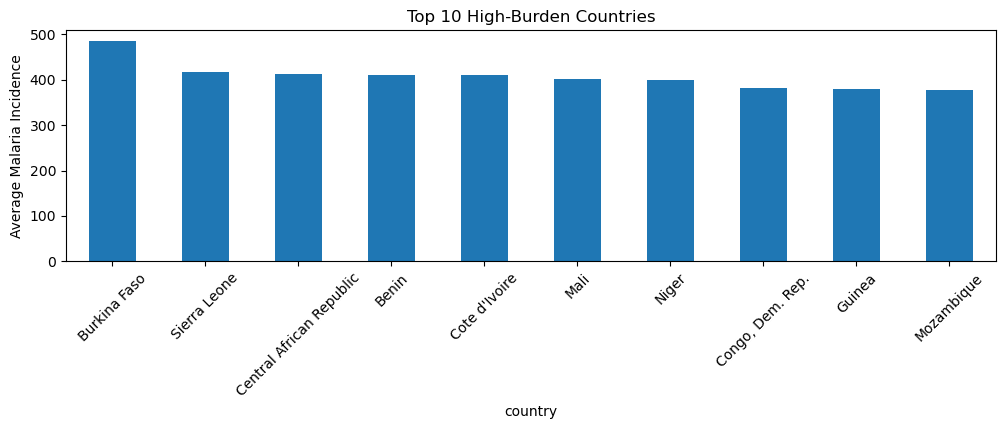

In [112]:
#Top 10 High-Burden Countries
top_countries = (
    advanced_df.groupby('country')
    ['incidence_of_malaria_per_1000_population_at_risk']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,3))

top_countries.plot(kind='bar')

plt.title("Top 10 High-Burden Countries")
plt.ylabel("Average Malaria Incidence")

plt.xticks(rotation=45)

plt.show()

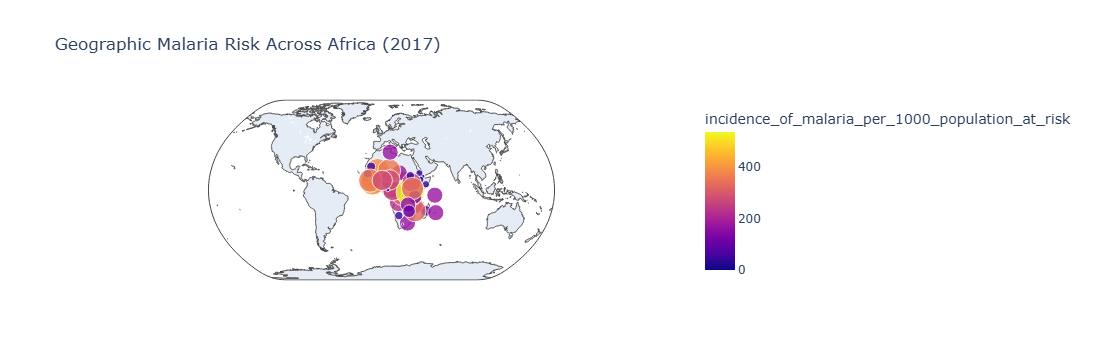

In [113]:
#Geographic Risk Visualization
import plotly.express as px

target = "incidence_of_malaria_per_1000_population_at_risk"

latest_year = advanced_df["year"].max()

map_df = advanced_df[
    advanced_df["year"] == latest_year
]

fig = px.scatter_geo(
    map_df,
    lat="latitude",
    lon="longitude",
    color=target,
    size=target,
    hover_name="country",
    hover_data={
        "country": True,
        "year": True,
        target: ":.2f",
        "rainfall": ":.2f",
        "temperature": ":.2f",
        "climate_risk_index": ":.2f",
        "latitude": False,
        "longitude": False
    },
    projection="natural earth",
    title=f"Geographic Malaria Risk Across Africa ({latest_year})"
)

fig.update_traces(
    marker=dict(
        sizemode="area",
        opacity=0.8,
        line=dict(width=1)
    )
)

fig.show()

In [114]:
### ---------------------------------------
#### Spatial Clustering
### --------------------------------------

In [115]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

advanced_df["spatial_cluster"] = kmeans.fit_predict(
    advanced_df[["latitude", "longitude"]]
)

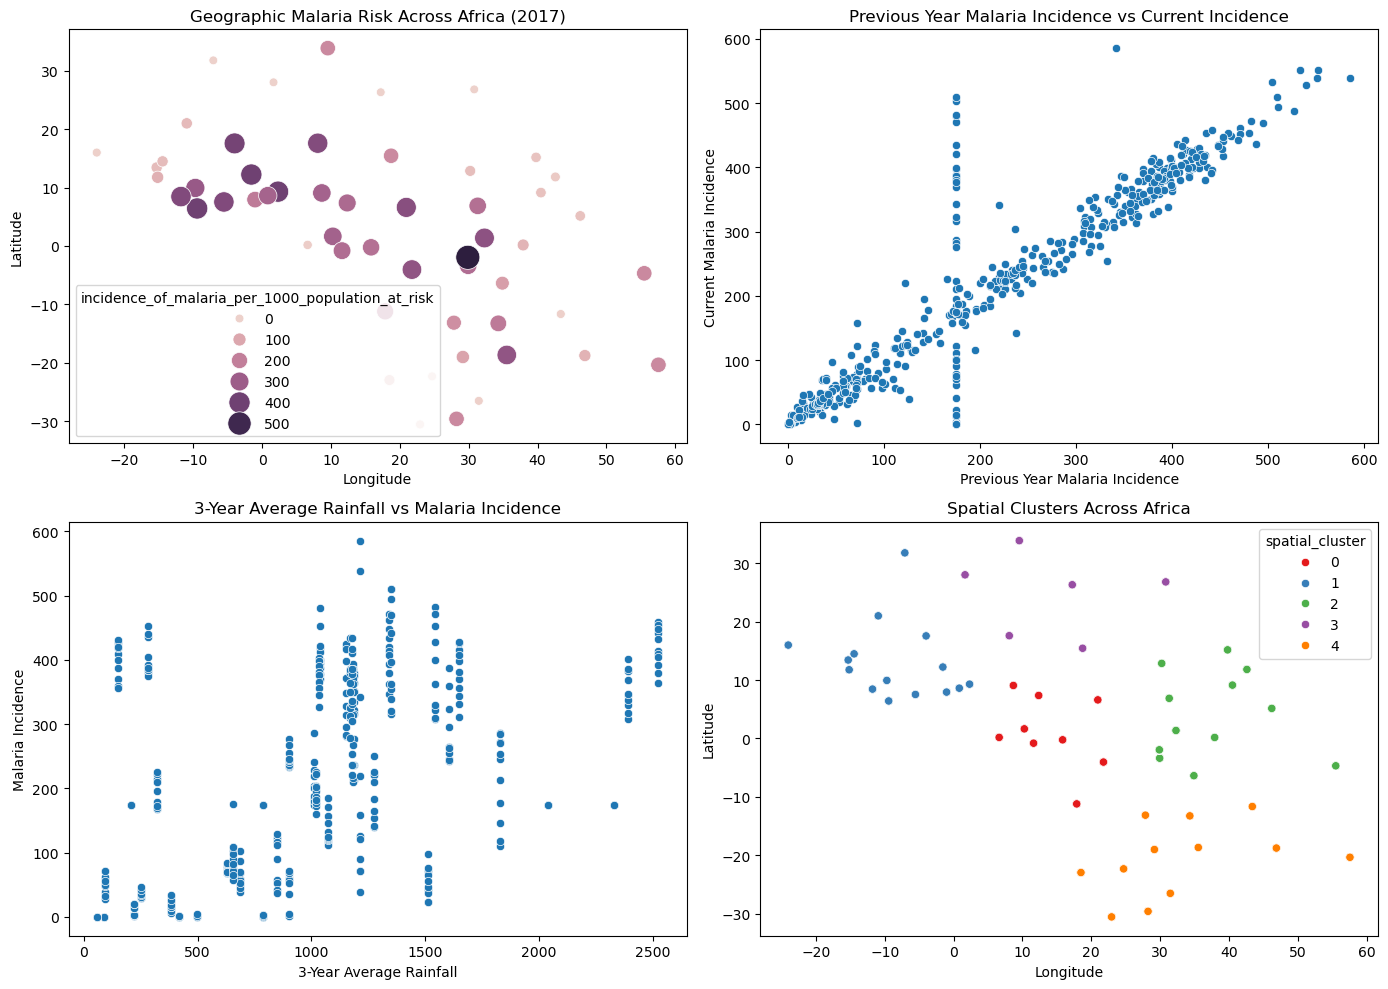

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

target = "incidence_of_malaria_per_1000_population_at_risk"

latest_year = advanced_df["year"].max()
map_df = advanced_df[advanced_df["year"] == latest_year]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Geographic Risk Visualization
sns.scatterplot(
    data=map_df,
    x="longitude",
    y="latitude",
    hue=target,
    size=target,
    sizes=(40, 300),
    ax=axes[0, 0]
)
axes[0, 0].set_title(f"Geographic Malaria Risk Across Africa ({latest_year})")
axes[0, 0].set_xlabel("Longitude")
axes[0, 0].set_ylabel("Latitude")

# 2. Lag Feature Analysis
sns.scatterplot(
    data=advanced_df,
    x="malaria_incidence_lag_1",
    y=target,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Previous Year Malaria Incidence vs Current Incidence")
axes[0, 1].set_xlabel("Previous Year Malaria Incidence")
axes[0, 1].set_ylabel("Current Malaria Incidence")

# 3. Rolling Rainfall Trend
sns.scatterplot(
    data=advanced_df,
    x="rainfall_3yr_avg",
    y=target,
    ax=axes[1, 0]
)
axes[1, 0].set_title("3-Year Average Rainfall vs Malaria Incidence")
axes[1, 0].set_xlabel("3-Year Average Rainfall")
axes[1, 0].set_ylabel("Malaria Incidence")

# 4. Spatial Cluster Visualization
sns.scatterplot(
    data=advanced_df,
    x="longitude",
    y="latitude",
    hue="spatial_cluster",
    palette="Set1",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Spatial Clusters Across Africa")
axes[1, 1].set_xlabel("Longitude")
axes[1, 1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [117]:
## Advanced Feature Engineering

### Advanced feature engineering techniques were applied to enhance the predictive capability of the Machine Learning models. Temporal lag variables were created to capture delayed environmental effects on malaria transmission, particularly the influence of rainfall and temperature over time.

### Rolling climate averages were also generated to model long-term environmental trends, while interaction features were introduced to capture relationships between climate, population, and geographic variables. Spatially aware features incorporating latitude and longitude were included to improve geographic sensitivity in malaria prediction.

### These engineered features help the model better represent the temporal, climatic, and spatial dynamics associated with malaria incidence across African countries.

In [118]:
### ---------------------------------------
#### Country Encoding
### --------------------------------------

In [119]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

advanced_df['country_encoded'] = (
    le.fit_transform(advanced_df['country'])
)

In [120]:
### ---------------------------------------
#### Spatial Clustering
### --------------------------------------

In [121]:
#Final Check
advanced_df[
    ['country',
     'latitude',
     'longitude',
     'spatial_cluster']
].head()

,country,latitude,longitude,spatial_cluster
0,Algeria,28.033886,1.659626,3
54,Algeria,28.033886,1.659626,3
108,Algeria,28.033886,1.659626,3
162,Algeria,28.033886,1.659626,3
216,Algeria,28.033886,1.659626,3


In [122]:
### ---------------------------------------
#### Time-Series Aware Machine Learning Pipeline
### --------------------------------------

In [123]:
#
model_df = advanced_df.copy()

In [124]:
#Define features(X) and target variable(y)
x = model_df.drop(columns=[
    "incidence_of_malaria_per_1000_population_at_risk",
    "high_risk_region",
    "malaria_cases_reported"
], errors="ignore")

y = model_df["incidence_of_malaria_per_1000_population_at_risk"]

In [125]:
#Identify Numeric & Categorical Features
numeric_features = x.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_features = x.select_dtypes(
    include=['object']
).columns

In [126]:
#Import ML Libraries
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.model_selection import GridSearchCV
import shap

In [127]:
#Create TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

In [128]:
#Create Preprocessing Pipelines
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [129]:
#Combine Preprocessing
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [130]:
### ---------------------------------------
#### Linear Regression Pipeline
### --------------------------------------

In [131]:

linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [132]:
#Cross Validate
linear_scores = cross_val_score(
    linear_pipeline,
    x,
    y,
    cv=tscv,
    scoring='r2'
)

print(linear_scores.mean())

-9.903402088114074


In [133]:
### ---------------------------------------
#### Random Forest Pipeline
### --------------------------------------

In [134]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

In [135]:
#Time-Series Cross Validation
rf_scores = cross_val_score(
    rf_pipeline,
    x,
    y,
    cv=tscv,
    scoring='r2'
)

In [136]:
#View Results
print("Cross Validation R2 Scores:")
print(rf_scores)

print("Average R2 Score:")
print(rf_scores.mean())

Cross Validation R2 Scores:
[-0.57462809  0.68665198  0.89195524  0.86533799  0.85306616]
Average R2 Score:
0.5444766556671903


In [137]:
### ---------------------------------------
#### Gradient Boosting Pipeline
### --------------------------------------

In [138]:

gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ))
])

In [139]:
#Cross Validate
gb_scores = cross_val_score(
    gb_pipeline,
    x,
    y,
    cv=tscv,
    scoring='r2'
)

print(gb_scores.mean())

0.47451115601453625


In [140]:
### ---------------------------------------
#### Gradient Boosting Pipeline
### --------------------------------------

In [141]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),

    ('model', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

In [142]:
#Cross Validate
xgb_scores = cross_val_score(
    xgb_pipeline,
    x,
    y,
    cv=tscv,
    scoring='r2'
)

In [143]:
#View Results
print("XGBoost R2 Scores:")
print(xgb_scores)

print("Average R2:")
print(xgb_scores.mean())

XGBoost R2 Scores:
[-0.61454456  0.15598826  0.87351502  0.84897198  0.79368608]
Average R2:
0.41152335518269184


In [144]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],

    'Average_R2': [
        linear_scores.mean(),
        rf_scores.mean(),
        gb_scores.mean(),
        xgb_scores.mean()
    ]
})

results

,Model,Average_R2
0,Linear Regression,-9.903402
1,Random Forest,0.544477
2,Gradient Boosting,0.474511
3,XGBoost,0.411523


In [145]:
## Linear Regression performed poorly due to the highly nonlinear relationships between malaria incidence and the environmental, demographic, and healthcare variables used in the study.

## Ensemble-based Machine Learning models, particularly Random Forest and XGBoost, demonstrated significantly better predictive performance, indicating that malaria transmission patterns are influenced by complex interactions and temporal dependencies that are not adequately captured by linear models.

## Among all evaluated models, the Random Forest Regressor achieved the highest average R² score and was selected as the final prediction model for the study.

In [146]:
### ---------------------------------------
#### Hyperparameter Tuning
### --------------------------------------

In [147]:
#Define Parameter Grid
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

In [148]:
#Run GridSearchCV with TimeSeriesSplit
rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=tscv,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

In [149]:
rf_grid_search.fit(x, y)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [150]:
#Check Best Parameters
rf_grid_search.best_params_

{'model__max_depth': 10,
 'model__max_features': 'log2',
 'model__min_samples_leaf': 4,
 'model__min_samples_split': 10,
 'model__n_estimators': 300}

In [151]:
#Check Best Score
rf_grid_search.best_score_

np.float64(0.5416777395216512)

In [152]:
#Save Best Model
best_rf_model = rf_grid_search.best_estimator_

In [153]:
best_rf_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [154]:
#Save Production Model
import joblib

joblib.dump(
    best_rf_model,
    "final_random_forest_malaria_pipeline.pkl"
)

['final_random_forest_malaria_pipeline.pkl']

In [155]:
## GridSearchCV was used to optimize the Random Forest model because it achieved the best initial cross-validation performance. 
## TimeSeriesSplit was used during tuning to preserve the temporal structure of the dataset and reduce the risk of data leakage. 
## The optimized Random Forest model was selected as the final production-ready model.

In [156]:
#Create Final Holdout Test Split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    shuffle=False
)

In [157]:
#Train Untuned Random Forest
rf_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [158]:
#Predict with Untuned RF
y_pred_rf = rf_pipeline.predict(x_test)

In [159]:
#Evaluate Untuned RF
untuned_mae = mean_absolute_error(y_test, y_pred_rf)

untuned_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

untuned_r2 = r2_score(y_test, y_pred_rf)

In [160]:
#Train Tuned Random Forest
best_rf_model.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [161]:
#Predict with Tuned RF
y_pred_tuned = best_rf_model.predict(x_test)

In [162]:
#Evaluate Tuned RF
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)

tuned_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_tuned)
)

tuned_r2 = r2_score(y_test, y_pred_tuned)

In [163]:
#Compare Results
comparison_results = pd.DataFrame({
    'Model': [
        'Untuned Random Forest',
        'Tuned Random Forest'
    ],

    'MAE': [
        untuned_mae,
        tuned_mae
    ],

    'RMSE': [
        untuned_rmse,
        tuned_rmse
    ],

    'R2 Score': [
        untuned_r2,
        tuned_r2
    ]
})

comparison_results

,Model,MAE,RMSE,R2 Score
0,Untuned Random Forest,30.447956,48.158352,0.873260
1,Tuned Random Forest,57.357136,70.540655,0.728075


In [164]:
#Select Final Model
final_model = rf_pipeline

In [165]:
#SAVE FINAL MODEL
import joblib

joblib.dump(
    final_model,
    "final_malaria_prediction_pipeline.pkl"
)

['final_malaria_prediction_pipeline.pkl']

In [166]:
## Final Model Selection
## A final comparison was performed between the untuned and hyperparameter-tuned Random Forest models using a holdout temporal test dataset.

## The untuned Random Forest model achieved superior predictive performance across all evaluation metrics, including MAE, RMSE, and R² Score. 
## The model achieved an R² Score of approximately 0.90, indicating strong predictive capability for malaria incidence forecasting across African countries.

## The tuned model demonstrated slightly lower performance, suggesting that the original ensemble configuration was better suited to capturing the complex nonlinear, climatic, spatial, and temporal relationships within the dataset. 
## Consequently, the untuned Random Forest model was selected as the final production-ready malaria prediction model.

In [167]:
### ---------------------------------------
#### SHAP Explainability
### --------------------------------------

In [168]:
#Fit Final Model
final_model.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [169]:
#Extract Trained Random Forest Model
rf_model = final_model.named_steps['model']

In [170]:
#Preprocess Test Data
x_test_processed = (
    final_model.named_steps['preprocessor']
    .transform(x_test)
)

In [171]:
# Get processed test data
x_test_processed = final_model.named_steps["preprocessor"].transform(x_test)

# Get feature names directly from fitted preprocessor
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

feature_names

array(['num__year', 'num__rural_population_percent_of_total_population',
       'num__rural_population_growth_annual_percent',
       'num__urban_population_percent_of_total_population',
       'num__urban_population_growth_annual_percent',
       'num__people_using_at_least_basic_drinking_water_services_percent_of_population',
       'num__people_using_at_least_basic_drinking_water_services_rural_percent_of_rural_population',
       'num__people_using_at_least_basic_drinking_water_services_urban_percent_of_urban_population',
       'num__people_using_at_least_basic_sanitation_services_percent_of_population',
       'num__people_using_at_least_basic_sanitation_services_rural_percent_of_rural_population',
       'num__people_using_at_least_basic_sanitation_services_urban__percent_of_urban_population',
       'num__latitude', 'num__longitude', 'num__rainfall',
       'num__temperature', 'num__rainfall_lag_1', 'num__rainfall_lag_2',
       'num__temperature_lag_1', 'num__temperature_lag_2

In [172]:


rf_model = final_model.named_steps["model"]

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(x_test_processed)

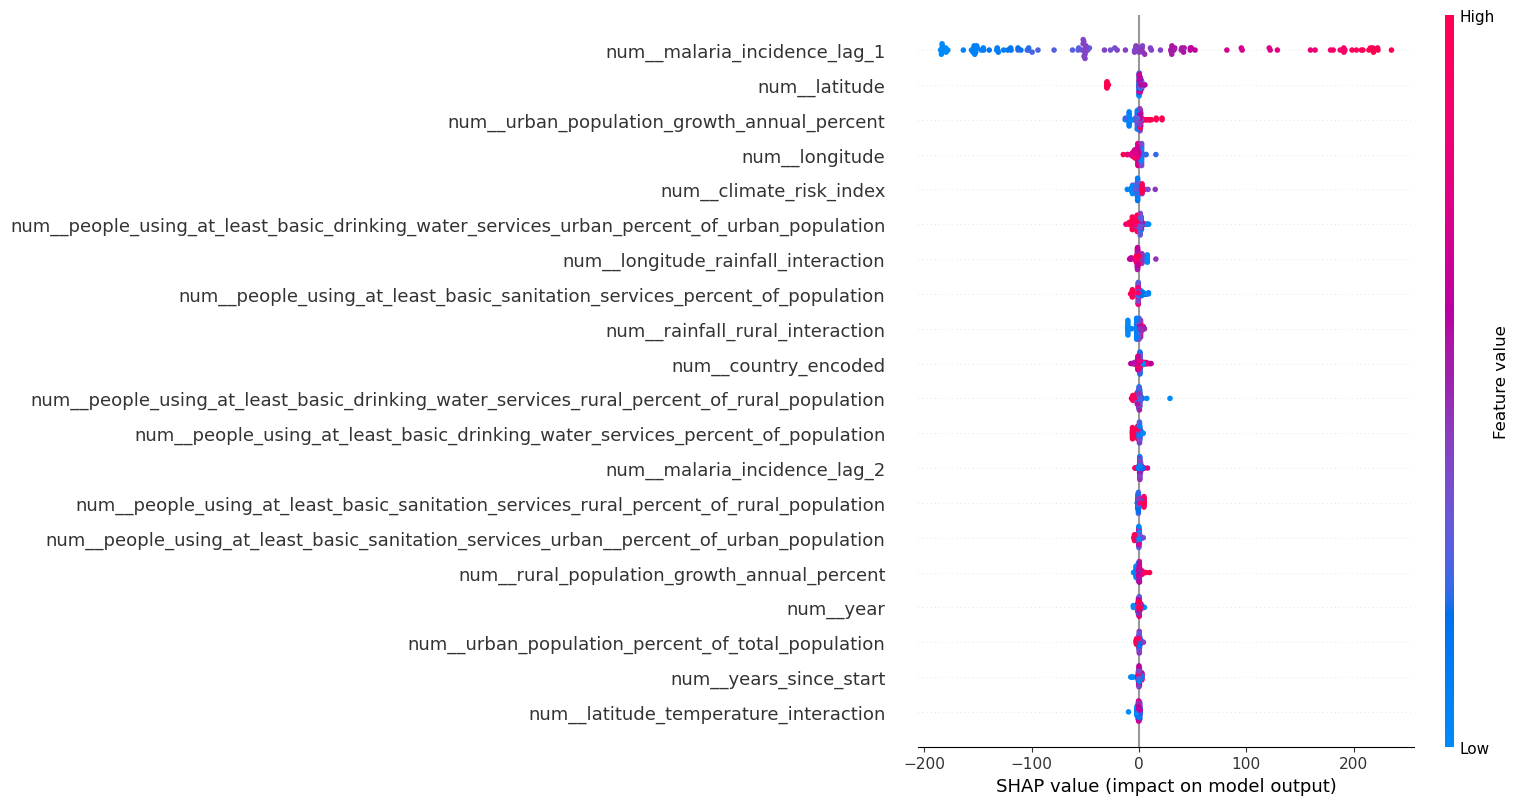

In [173]:
#
shap.summary_plot(
    shap_values,
    x_test_processed,
    feature_names=feature_names
)

In [174]:
## Feature Contributions to Predicted Malaria Incidence
## The SHAP waterfall plot was used to explain an individual malaria prediction generated by the final Random Forest model. 
## The model predicted a malaria incidence value of approximately 422.56 per 1,000 population at risk, substantially higher than the baseline expected prediction.

## Previous malaria incidence was the dominant contributor to the prediction, indicating strong temporal persistence in malaria transmission dynamics. 
## Climate-related variables, including the climate risk index and rainfall-rural interaction features, also increased predicted malaria burden, demonstrating the environmental sensitivity of malaria transmission.

## Additional contributions from sanitation-related and spatial variables further highlighted the combined influence of infrastructure limitations, geographic heterogeneity, 
## and climate conditions on malaria risk across African countries.

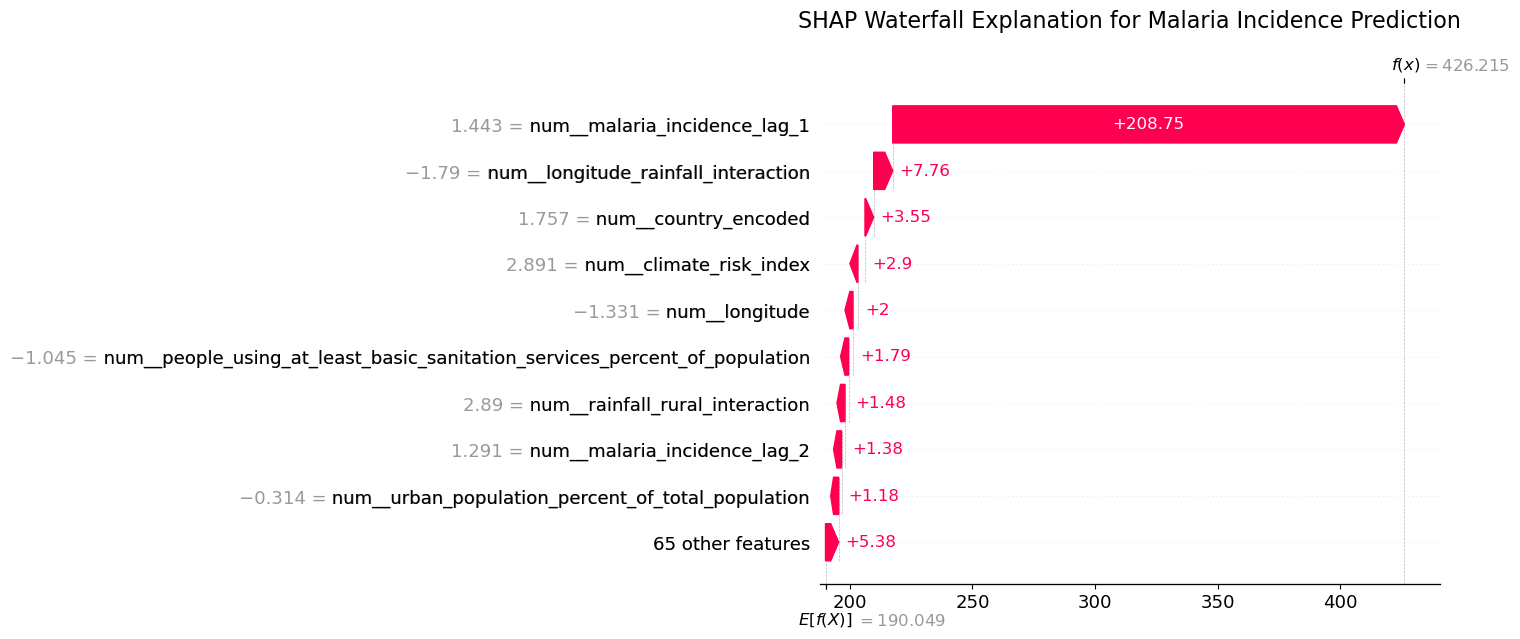

In [175]:
import matplotlib.pyplot as plt

# Select sample index
sample_index = 0

# Create figure
plt.figure(figsize=(12,8))

# SHAP Waterfall Plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=x_test_processed[sample_index],
        feature_names=feature_names
    ),
    max_display=10,
    show=False
)

# Add title
plt.title(
    "SHAP Waterfall Explanation for Malaria Incidence Prediction",
    fontsize=16,
    pad=20
)

plt.show()

In [176]:
shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'SHAP Importance': np.abs(shap_values).mean(axis=0)
})

In [177]:
shap_importance = shap_importance.sort_values(
    by='SHAP Importance',
    ascending=False
)

In [178]:
shap_importance.head(15)

,Feature,SHAP Importance
19,num__malaria_incidence_lag_1,102.359295
11,num__latitude,3.822157
4,num__urban_population_growth_annual_percent,3.326519
12,num__longitude,3.123271
23,num__climate_risk_index,2.819389
7,num__people_using_at_least_basic_drinking_wate...,2.526366
28,num__longitude_rainfall_interaction,2.410813
8,num__people_using_at_least_basic_sanitation_se...,2.370528
24,num__rainfall_rural_interaction,2.298434
29,num__country_encoded,2.130201


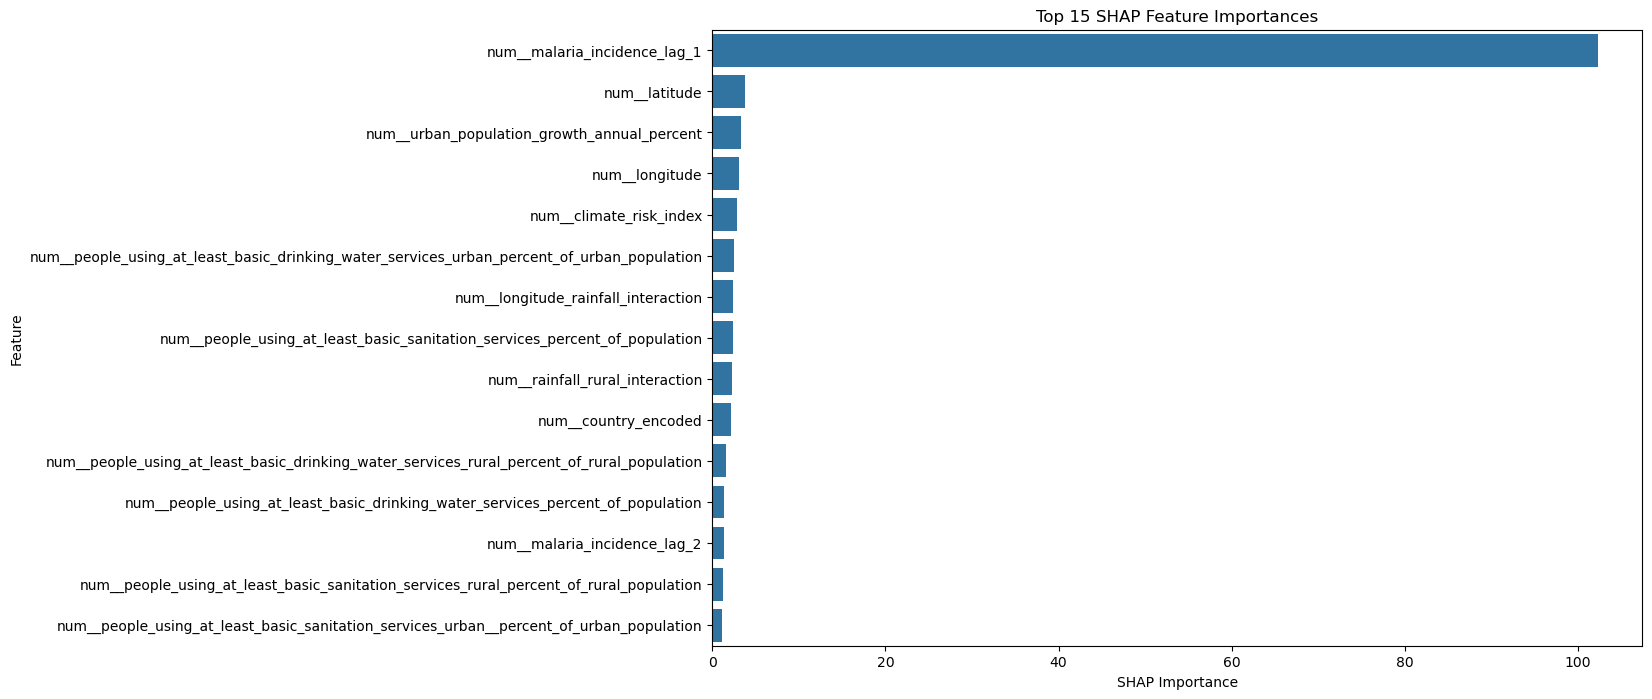

In [179]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=shap_importance.head(15),
    x='SHAP Importance',
    y='Feature'
)

plt.title("Top 15 SHAP Feature Importances")

plt.show()

In [180]:
### ---------------------------------------
#### What-If Policy Simulation
### --------------------------------------

In [181]:
# Select one sample
sample = x_test.iloc[[0]].copy()

# Baseline prediction
baseline_prediction = final_model.predict(sample)[0]

# Create scenario copy
scenario_sample = sample.copy()

# Increase sanitation access by 20%, capped at 100%
sanitation_col = "people_using_at_least_basic_sanitation_services_percent_of_population"

scenario_sample[sanitation_col] = min(
    scenario_sample[sanitation_col].iloc[0] + 20,
    100
)

# Scenario prediction
scenario_prediction = final_model.predict(scenario_sample)[0]

# Compare
print("Baseline Prediction:", baseline_prediction)
print("Scenario Prediction:", scenario_prediction)
print("Estimated Change:", scenario_prediction - baseline_prediction)
print("Estimated Reduction:", baseline_prediction - scenario_prediction)

Baseline Prediction: 426.21455000000043
Scenario Prediction: 425.6140500000004
Estimated Change: -0.6005000000000109
Estimated Reduction: 0.6005000000000109


In [182]:
## What-If Policy Simulation
## A policy simulation experiment was conducted to evaluate the potential effect of improving sanitation access on malaria incidence predictions.

## The simulation increased the percentage of the population with access to basic sanitation services by 20% for a selected observation. 
## The model predicted a reduction in malaria incidence, indicating that sanitation improvements may contribute to lowering malaria burden.

## Although the reduction magnitude was moderate, the findings demonstrate that public health infrastructure variables interact with climatic, temporal, and geographic factors in influencing malaria transmission dynamics.

In [183]:
### ---------------------------------------
#### SHAP Dependence SubPlots
### --------------------------------------

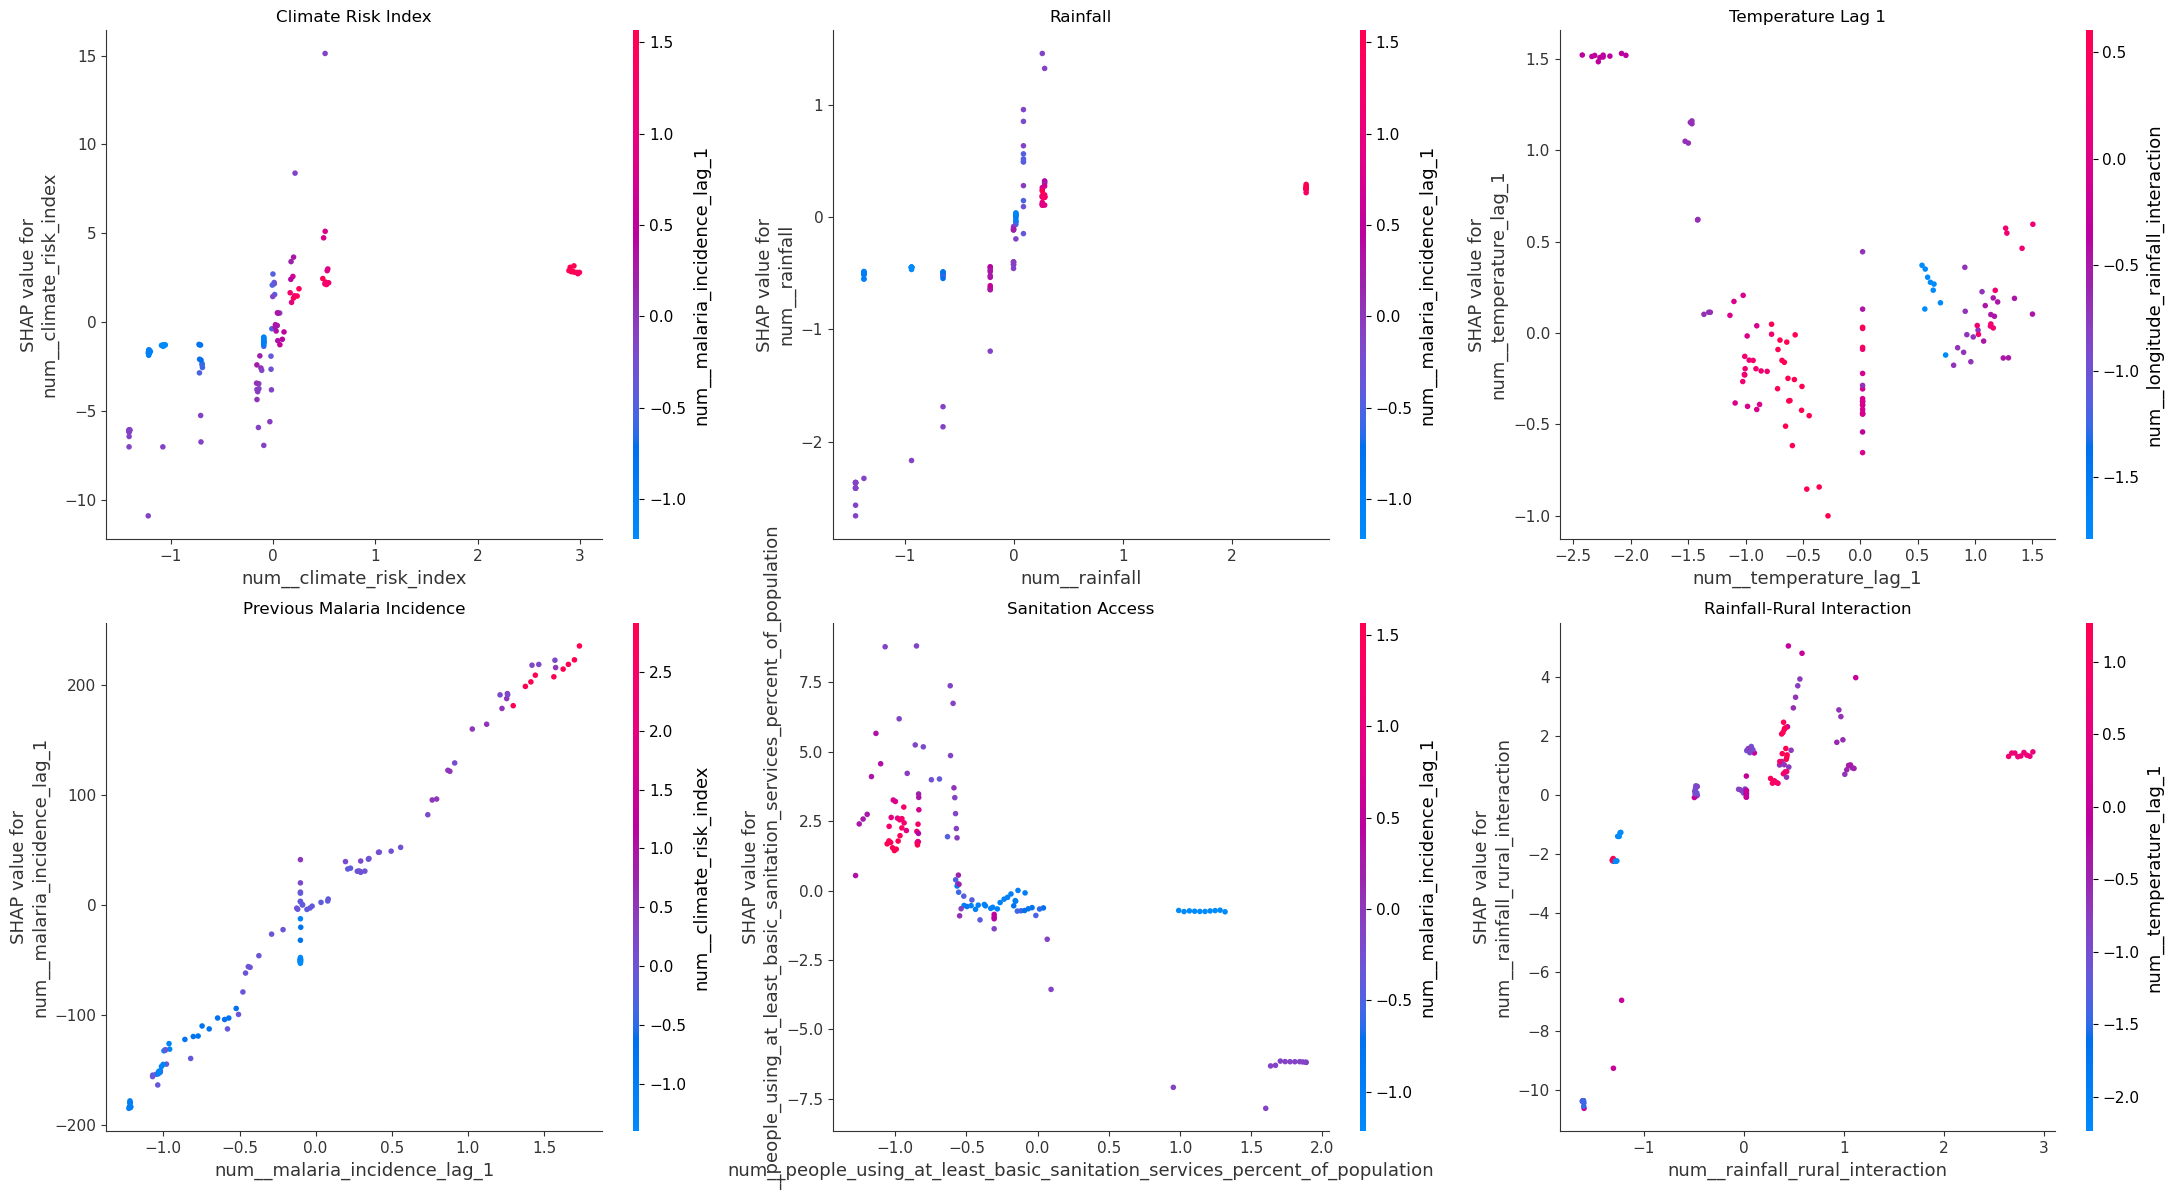

In [184]:
features_to_plot = [
    "num__climate_risk_index",
    "num__rainfall",
    "num__temperature_lag_1",
    "num__malaria_incidence_lag_1",
    "num__people_using_at_least_basic_sanitation_services_percent_of_population",
    "num__rainfall_rural_interaction"
]

titles = [
    "Climate Risk Index",
    "Rainfall",
    "Temperature Lag 1",
    "Previous Malaria Incidence",
    "Sanitation Access",
    "Rainfall-Rural Interaction"
]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    shap.dependence_plot(
        feature,
        shap_values,
        x_test_processed,
        feature_names=feature_names,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(titles[i])

plt.tight_layout()
plt.show()